# Basic Multinomial Logistic Regression

In [9]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression model
model = LogisticRegression(solver="lbfgs", max_iter=1000)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


# With Standardization

In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

1.0

# Probability Prediction

In [11]:
y_prob = model.predict_proba(X_test)

print("First 5 probability rows:")
print(y_prob[:5])

First 5 probability rows:
[[3.80340885e-03 8.27739568e-01 1.68457023e-01]
 [9.46966698e-01 5.30331036e-02 1.98782019e-07]
 [8.85899833e-09 1.54852623e-03 9.98451465e-01]
 [6.48503376e-03 7.92228916e-01 2.01286050e-01]
 [1.45754730e-03 7.74128804e-01 2.24413649e-01]]


# Confusion Matrix + Classification Report

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# With Regularization (L2)

In [14]:
from sklearn.linear_model import LogisticRegression

model_l2 = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000
)

model_l2.fit(X_train, y_train)

print("Accuracy:", model_l2.score(X_test, y_test))

Accuracy: 1.0


# L1 Regularization (Sparse Multinomial)

In [16]:
model_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=1000
)

model_l1.fit(X_train, y_train)
print("Accuracy:", model_l1.score(X_test, y_test))

Accuracy: 1.0


# LogisticRegressionCV (Auto Hyperparameter)

In [19]:
from sklearn.linear_model import LogisticRegressionCV

log_cv = LogisticRegressionCV(
    solver="lbfgs",
    cv=5,
    max_iter=1000
)

log_cv.fit(X_train, y_train)

print("Best Accuracy:", log_cv.score(X_test, y_test))

Best Accuracy: 1.0


# Decision Boundary Visualization

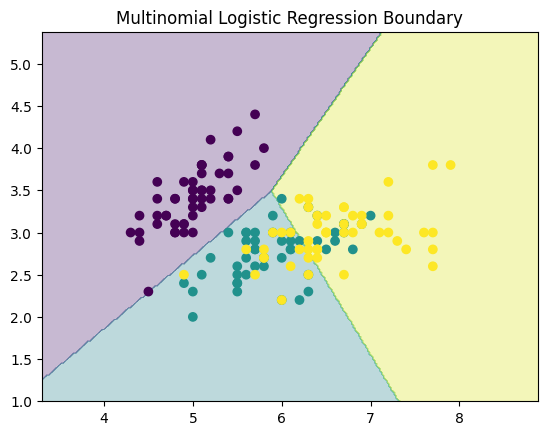

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# Use only 2 features for visualization
X_vis = X[:, :2]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)

model_vis = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

model_vis.fit(X_train_v, y_train_v)

# Plot
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y)
plt.title("Multinomial Logistic Regression Boundary")
plt.show()